# Sharpe Style Analysis

Sharpe Style Analysis is an elegant and simple decomposition exercise similar to what we did in the previous lab session, with the added constraint that the coefficients are all positive and add to 1.

Therefore, the coefficients of performing style analysis on the observed return of a manager can be interpreted as weights in a portfolio of building blocks which together, _mimic_ that return series. The exercise can reveal drifts in a manager's style as well as provide insight into what the manager is likely doing to obtain the returns.


# Performing Sharpe Style Analysis

The key to obtaining the weights is our old friend, the quadriatic optimizer. We are asking the optimizer to find the weights that minimizes the square of the difference between the observed series and the returns of a benchmark portfolio that holds the explanatory building blocks in those same weights. This is equivalent to minimizing the _tracking error_ between the two return series.

In [1]:
import numpy as np
import pandas as pd
import risk_kit as rk

%load_ext autoreload
%autoreload 2

In [2]:
ind = rk.get_ind_returns()['2000':]

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:65: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',


Let's construct a manager that invests in 30% Beer, 50% in Smoke and 20% in other things that have an average return of 0% and an annualized vol of 15%

In [3]:
mgr_r = 0.3 * ind['Beer'] + 0.5 * ind['Smoke'] + 0.2 * np.random.normal(scale = 0.15/(12**.5), size = ind.shape[0]) # Volatility scales with the square root of time

Now, assume we knew absolutely nothing about this manager and all we observed was the returns. How could we tell what she was invested in?

In [5]:
weights = rk.style_analysis(mgr_r, ind) * 100

<Axes: >

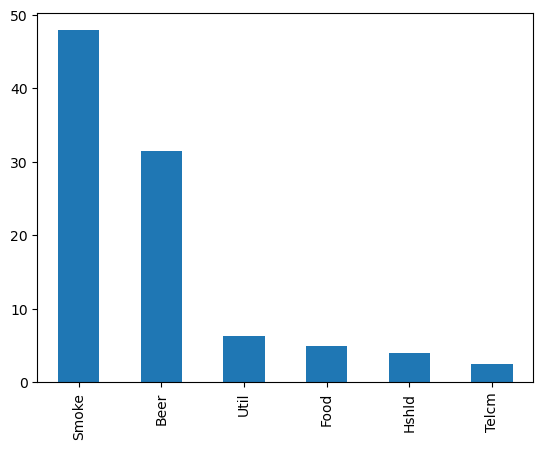

In [8]:
weights.sort_values(ascending = False).head(6).plot.bar()

Contrast this to the results of a regression. Because the model is in fact very true (i.e. we really did construct the manager's returns out of the building blocks), the results are remarkably accurate. However, the negative coefficients are hard to intepret and in real-life data, those will be much larger. However when it works well, such as in this artificial example here, the results can be very accurate.

In [9]:
coeffs = rk.regress(mgr_r, ind).params*100
coeffs.sort_values().head()

Books   -7.180561
Carry   -5.693886
Meals   -3.448566
ElcEq   -3.206859
Whlsl   -3.192546
dtype: float64

<Axes: >

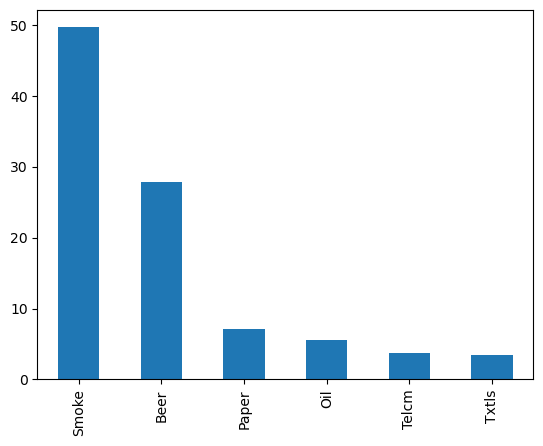

In [10]:
coeffs.sort_values(ascending=False).head(6).plot.bar()

#### Regression can return negative coefficients that are hard to interpret as portfolio weights, whereas a constrained optimizer can enforce long-only/bounds to keep weights interpretable.

# Warning: Potential Misuse of Style Analysis

Style analysis (return-based holdings inference) tries to explain **Buffett/Berkshire’s** returns as a weighted mix of a few benchmark/index returns (the explanatory variables). The fitted weights are often interpreted like “Berkshire is X% in this, Y% in that.”

It works best when the benchmarks you choose closely match what Berkshire is actually exposed to (e.g., a broad equity index plus value/quality, size, and a bond/credit proxy).

The main risk is that style analysis is *forced* to produce an answer even when your benchmark set is wrong or incomplete. It will always find some set of weights that best matches Berkshire’s return series among the choices you gave it, but those weights may not reflect reality—only the best approximation within a potentially bad menu.

You can compute a goodness-of-fit measure (similar to an (R^2)) to see how much variation the fitted mix explains. However, even a decent fit does not guarantee the interpretation is correct (different benchmark mixes can mimic each other), while a poor fit is a clear warning sign.

For Buffett/Berkshire specifically, results can be misleading if your factors don’t capture key features like **concentrated stock positions, insurance float/leverage effects, large exposures to specific industries (e.g., financials/energy), private operating businesses, and time-varying holdings**. The algorithm will still return weights, but they can be economically implausible.

By contrast, when the specification is accurate—as with an artificially generated return series constructed from a known factor mix—the recovered weights can be very revealing.
